# Fused Pipeline v5: Semi-Supervised ResNet-50 + Wavelet Hybrid — Breast Cancer Classification

**v1 -> v2 -> v3 -> v4 -> v5**, based on running each version and comparing actual results:

- **v1**: overfit badly (train F1 99.9% / val F1 70%), test macro F1 70.6%.
- **v2**: fixed the overfitting, but self-training was quietly re-skewing the dataset toward Normal
  (78% of all accepted pseudo-labels). Test macro F1 barely moved (69.4%).
- **v3**: fixed the self-training skew with a per-class threshold + cap (verified working). Test macro
  F1 still barely moved (69.95%) -- per-class report showed Benign (F1 0.57) dragging the average down
  while Malignant (0.74) and Normal (0.79) were fine.
- **v4**: added a *measured* (not hand-picked) class weight targeting whichever class had the worst
  recall, and printed the raw confusion matrix for the first time. Result: **test macro F1 = 70.09%,
  essentially flat again (+0.14 points).** But the new confusion-matrix printout revealed the actual
  problem for the first time: Benign and Malignant are confused with **each other** far more than either
  is confused with Normal (Benign->Malignant 32.0%, Malignant->Benign 24.2%, vs. only 4-8% either way
  into/from Normal). Per-class recall weighting can't fix that -- it treats each class's error rate
  independently, when the real error is concentrated on one specific pairwise boundary. A second clue
  pointed the same way: during self-training, Malignant repeatedly landed well below its 200-per-
  iteration cap (111, then 105) while Benign and Normal both saturated it -- the model isn't
  under-confident on Malignant in general, it's specifically unsure between Benign and Malignant.

## What's new in v5 -- all aimed at the Benign<->Malignant boundary specifically

1. **NEW `CLASS_WEIGHT_MODE = 'pairwise_confusion'` (new default).** Instead of weighting each class by
   its own recall (v4), this measures the val confusion matrix's Benign<->Malignant cross-confusion
   rate specifically and boosts *both* classes' loss weight together, scaled by how severe that
   specific confusion actually is (`PAIRWISE_BOOST_SCALE`). Normal is left at 1.0 -- it was never the
   problem.
2. **NEW: margin-gated self-training for the confused pair.** When self-training's pseudo-label is
   Benign or Malignant, it's no longer enough to clear the confidence threshold -- the gap between the
   top and second-highest class probability must also clear `MARGIN_REQUIRED_FOR_PAIR`. A pseudo-label
   of "Benign, 0.86" when Malignant scored 0.80 is exactly the kind of barely-decided call that, if fed
   back into training as ground truth, would entrench the existing confusion rather than fix it. Normal
   pseudo-labels are unaffected (that class was never the problem, per the actual per-class acceptance
   log).
3. **NEW: GLCM texture features, added to the wavelet feature vector.** DWT energy/entropy/contrast
   captures multiscale texture, but the clinical basis for telling benign from malignant findings is
   largely about **margin regularity** (smooth vs. spiculated/irregular) -- exactly what
   Gray-Level Co-occurrence Matrix (GLCM) properties (contrast, homogeneity, correlation, energy,
   dissimilarity, ASM) are designed to capture and DWT sub-band statistics are not. These are
   concatenated onto the existing wavelet vector (still called `WAVELET_FEATURE_DIM` / `wavelet_input`
   to minimize renaming -- it's now a combined DWT+GLCM handcrafted-feature vector).
4. **NEW: optional focal loss (`USE_FOCAL_LOSS`, off by default).** Focuses gradient on hard,
   currently-misclassified examples regardless of class -- a natural complement to (1) if pairwise
   weighting alone isn't enough. Easy to toggle on if v5's first run still shows the same confusion.
5. **NEW: a Benign-vs-Malignant-only accuracy metric**, printed at final evaluation, so progress on the
   actual target problem is visible directly each run instead of being inferred from the full 3-class
   report and confusion matrix by hand.

Everything that measurably worked in earlier versions is unchanged: per-class threshold + cap for
Normal's self-training, flip-only augmentation, the three-phase structure, `FINETUNE_UNFREEZE_LAST_N`
(train/test F1 gap this run was 84.5% vs 70.1% -- present but not the dominant problem this time).

### Pipeline phases (unchanged)
- **Phase 1** — train the frozen-backbone hybrid model on `labeled_train` only (augmented).
- **Phase 2** — iterative self-training: per-class threshold + cap (all classes), plus a margin
  requirement for Benign/Malignant pseudo-labels specifically.
- **Phase 3** — lighter fine-tuning of the ResNet-50 backbone, now with pairwise-confusion-aware
  class weighting.
- **Phase 4** — evaluate on train/val/test; classification report; confusion matrix (plot + raw
  numbers + Benign-vs-Malignant-only accuracy).

### Expected data layout (unchanged)
```
Semi_Supervised_Balanced/
    labeled_train/<class>/*.jpg
    unlabeled_train/<class or single dummy folder>/*.jpg
    val/<class>/*.jpg
    test/<class>/*.jpg
```


In [1]:
# ==========================================================
# GPU CHECK
# ==========================================================
import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
print("TensorFlow Version: ", tf.__version__)


Num GPUs Available:  1
TensorFlow Version:  2.10.0


In [2]:
# ==========================================================
# IMPORTS
# ==========================================================
print("start")

import os
import shutil
import random
import numpy as np
import cv2
import pywt
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from skimage.feature import graycomatrix, graycoprops   # v5 NEW -- GLCM texture features

from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Dense, GlobalAveragePooling2D, Dropout, Concatenate, BatchNormalization
)
from tensorflow.keras import regularizers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import Sequence
from tensorflow.keras.metrics import Precision, Recall
import tensorflow_addons as tfa
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint,
    Callback
)

print("done1")


start
done1


In [3]:
# ==========================================================
# SEMI-SUPERVISED DATASET DIRECTORY (BALANCED)
# ==========================================================
print("start")

base_path = r"D:\Thesis_folder\Preprocessed_Pipeline\Semi_Supervised_Balanced"

labeled_dir = os.path.join(base_path, "labeled_train")
unlabeled_dir = os.path.join(base_path, "unlabeled_train")
val_dir = os.path.join(base_path, "val")
test_dir = os.path.join(base_path, "test")
train_combined_dir = os.path.join(base_path, "train_combined")

for split_dir in [labeled_dir, unlabeled_dir, val_dir, test_dir]:
    if not os.path.isdir(split_dir):
        raise FileNotFoundError(
            f"'{split_dir}' not found. Run the preprocessing pipeline "
            "(P3_fixed_final_Pipeline_v11) through the semi-supervised split step first."
        )
    classes_found = [d for d in os.listdir(split_dir) if os.path.isdir(os.path.join(split_dir, d))]
    counts = {cls: len(os.listdir(os.path.join(split_dir, cls))) for cls in classes_found}
    print(f"{os.path.basename(split_dir)}: {counts}")

print("done1")


start
labeled_train: {'Benign': 1714, 'Malignant': 1714, 'Normal': 1715}
unlabeled_train: {'Benign': 4286, 'Malignant': 4286, 'Normal': 4285}
val: {'Benign': 931, 'Malignant': 1239, 'Normal': 795}
test: {'Benign': 888, 'Malignant': 1266, 'Normal': 789}
done1


In [4]:
# ==========================================================
# CONFIGURATION & PARAMETERS  (v5)
# ==========================================================
print("start")

IMAGE_SIZE = (288, 288)
MODEL_INPUT_SIZE = (288, 288, 3)
NUM_CLASSES = 3
BATCH_SIZE = 32
EPOCHS_PHASE1 = 150

WAVELET_NAME = "db1"
WAVELET_LEVEL = 2

# --- GLCM texture features (v5 NEW) ---
# Targets margin/texture regularity specifically -- the clinical basis for telling benign
# (smooth, homogeneous) from malignant (irregular, heterogeneous) findings apart, which DWT
# energy/entropy/contrast statistics don't directly capture.
GLCM_LEVELS = 32
GLCM_DISTANCES = [1, 3]
GLCM_ANGLES = [0, np.pi / 4, np.pi / 2, 3 * np.pi / 4]
GLCM_PROPERTIES = ["contrast", "dissimilarity", "homogeneity", "energy", "correlation", "ASM"]

# --- Semi-supervised self-training schedule ---
NUM_ITERATIONS = 5
EPOCHS_PER_ITERATION = 7
CONFIDENCE_THRESHOLD = 0.90

PER_CLASS_THRESHOLD = {
    "Normal": 0.93,
    "Benign": 0.85,
    "Malignant": 0.85,
}
MAX_ACCEPT_PER_CLASS_PER_ITER = 200

# v5 NEW: last run's per-iteration log showed Malignant landing well below its own 200 cap (111,
# then 105) while Benign and Normal both saturated it -- i.e. the model isn't broadly unconfident on
# Malignant, it's specifically unsure between Benign and Malignant. A confidence threshold alone can't
# tell "genuinely confident" apart from "barely picked Benign over Malignant" -- a margin requirement
# can. Applied only to the confused pair; Normal's self-training already works fine as-is.
CONFUSED_PAIR_CLASSES = {"Benign", "Malignant"}
MARGIN_REQUIRED_FOR_PAIR = 0.25   # top-class prob minus second-highest prob, required for Benign/Malignant only

SELFTRAIN_EARLYSTOP_PATIENCE = 3

# --- Fine-tuning schedule ---
EPOCHS_FINETUNE = 25
FINETUNE_UNFREEZE_LAST_N = 10   # unchanged from v4 -- last run's train/test F1 gap (84.5%/70.1%) is
                                 # present but not the dominant problem this time; not touched further.

# --- Regularization (unchanged) ---
DROPOUT_RATE = 0.4
L2_REG = 1e-4

# --- Data augmentation (unchanged) ---
AUGMENT_TRAIN = True
USE_GAUSSIAN_NOISE = False
GAUSSIAN_NOISE_STD = 4.0

# --- Loss function (v5 NEW, optional) ---
# Off by default. If pairwise class weighting alone doesn't move the confusion enough, try turning
# this on -- focal loss focuses gradient on hard/misclassified examples generally, complementing (not
# replacing) the pairwise weighting above.
USE_FOCAL_LOSS = False
FOCAL_GAMMA = 2.0

# --- Class weighting (v5: rewritten again) ---
# v4's 'recall_inverse' measured each class's OWN recall independently and computed near-1.0 weights
# ({'Benign': 1.115, 'Malignant': 1.009, 'Normal': 0.9}) -- too weak to matter, and the wrong shape of
# fix anyway: the actual error (per v4's own confusion-matrix printout) is concentrated on Benign and
# Malignant being confused with EACH OTHER (32.0% / 24.2%), not on either class's recall being broadly
# low. 'pairwise_confusion' targets that directly: it measures the Benign<->Malignant cross-confusion
# rate from the val confusion matrix and boosts both classes' weight together, scaled by how severe
# that specific confusion is. Normal is left at 1.0.
#
#   None                 -- disabled
#   'balanced'            -- sklearn inverse-frequency (near no-op here; labeled_train is already
#                            frequency-balanced -- kept only for completeness)
#   'recall_inverse'      -- v4's per-class approach (kept available, not recommended given the
#                            diagnosis above)
#   'pairwise_confusion'  -- v5 NEW default; see above
CLASS_WEIGHT_MODE = "pairwise_confusion"
CLASS_WEIGHT_MAX_MULTIPLIER = 3.0
PAIRWISE_BOOST_SCALE = 3.0   # boost = 1 + confusion_severity * PAIRWISE_BOOST_SCALE, capped at
                              # CLASS_WEIGHT_MAX_MULTIPLIER. Last run's confusion_severity was ~0.28,
                              # giving a boost of ~1.84 -- a much more meaningful nudge than v4's ~1.1.

print("done1")


start
done1


In [5]:
# ==========================================================
# HANDCRAFTED FEATURE EXTRACTION: WAVELET (DWT) + GLCM  (v5: GLCM added)
# ==========================================================
# DWT sub-band statistics (mean/std/energy, unchanged from v1-v4) capture multiscale texture.
# GLCM properties (v5 NEW) capture margin/edge regularity specifically -- smooth/homogeneous
# (benign-leaning) vs. irregular/heterogeneous (malignant-leaning) -- which is the actual clinical
# basis for the Benign<->Malignant distinction and isn't something DWT energy stats target directly.
# Both are computed from the same grayscale image and concatenated into one feature vector, still
# called WAVELET_FEATURE_DIM / fed into the "wavelet_input" branch, to avoid a large rename across
# the generator and model code below.
print("start")

def extract_wavelet_features_from_gray(gray, wavelet=WAVELET_NAME, level=WAVELET_LEVEL):
    coeffs = pywt.wavedec2(gray, wavelet=wavelet, level=level)
    features = []
    for idx, c in enumerate(coeffs):
        sub_bands = [c] if idx == 0 else list(c)
        for sub in sub_bands:
            features.append(sub.mean())
            features.append(sub.std())
            features.append(np.sum(sub.astype(np.float64) ** 2) / sub.size)
    return np.array(features, dtype=np.float32)


def extract_glcm_features_from_gray(gray, levels=GLCM_LEVELS, distances=GLCM_DISTANCES, angles=GLCM_ANGLES):
    img_scaled = (gray.astype(np.float32) / 255.0 * (levels - 1)).astype(np.uint8)
    glcm = graycomatrix(img_scaled, distances=distances, angles=angles,
                         levels=levels, symmetric=True, normed=True)
    feats = []
    for prop in GLCM_PROPERTIES:
        vals = graycoprops(glcm, prop)
        feats.append(float(vals.mean()))
        feats.append(float(vals.std()))
    return np.array(feats, dtype=np.float32)


def extract_wavelet_features(image_rgb, wavelet=WAVELET_NAME, level=WAVELET_LEVEL):
    """
    image_rgb: HxWx3 uint8 or float array (0-255 range)
    Returns: 1D float32 feature vector = [DWT stats] + [GLCM stats]  (v5)
    """
    gray = cv2.cvtColor(image_rgb.astype(np.uint8), cv2.COLOR_RGB2GRAY)
    wav_feats = extract_wavelet_features_from_gray(gray, wavelet, level)
    glcm_feats = extract_glcm_features_from_gray(gray)
    return np.concatenate([wav_feats, glcm_feats]).astype(np.float32)


def get_wavelet_feature_dim():
    dummy = np.zeros((IMAGE_SIZE[0], IMAGE_SIZE[1], 3), dtype=np.uint8)
    return extract_wavelet_features(dummy).shape[0]


WAVELET_FEATURE_DIM = get_wavelet_feature_dim()
print(f"Combined DWT+GLCM feature vector length: {WAVELET_FEATURE_DIM}  "
      f"(was 21 with DWT alone in v1-v4)")
print("done1")

# PERFORMANCE NOTE: GLCM computation adds real per-image cost on top of the existing DWT call
# (a 288x288 image at 32 gray levels, 2 distances x 4 angles). If this becomes a training-speed
# bottleneck, reduce GLCM_ANGLES to fewer directions or GLCM_LEVELS to 16 first.


start
Combined DWT+GLCM feature vector length: 33  (was 21 with DWT alone in v1-v4)
done1


In [6]:
# ==========================================================
# AUGMENTATION (unchanged from v4)
# ==========================================================
print("start")

def augment_image(img_rgb):
    if random.random() < 0.5:
        img_rgb = np.ascontiguousarray(np.fliplr(img_rgb))
    if USE_GAUSSIAN_NOISE:
        noise = np.random.normal(0.0, GAUSSIAN_NOISE_STD, img_rgb.shape).astype(np.float32)
        img_rgb = np.clip(img_rgb.astype(np.float32) + noise, 0, 255).astype(np.uint8)
    return img_rgb

print("done1")


start
done1


In [7]:
# ==========================================================
# DUAL-INPUT DATA GENERATOR (ResNet-50 image branch + wavelet+GLCM branch)  (unchanged from v4)
# ==========================================================
class ResNetWaveletGenerator(Sequence):
    def __init__(self, directory, image_size=IMAGE_SIZE, batch_size=BATCH_SIZE,
                 num_classes=NUM_CLASSES, shuffle=True, labeled=True,
                 class_indices=None, exclude_filepaths=None, augment=False):
        self.directory = directory
        self.image_size = image_size
        self.batch_size = batch_size
        self.num_classes = num_classes
        self.shuffle = shuffle
        self.labeled = labeled
        self.augment = augment

        self.class_names = sorted(
            d for d in os.listdir(directory)
            if os.path.isdir(os.path.join(directory, d))
        )
        self.class_indices = class_indices or {name: i for i, name in enumerate(self.class_names)}

        exclude_filepaths = exclude_filepaths or set()

        self.filepaths = []
        self.labels = []
        for cls in self.class_names:
            cls_dir = os.path.join(directory, cls)
            for fname in os.listdir(cls_dir):
                if fname.lower().endswith((".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff")):
                    fpath = os.path.join(cls_dir, fname)
                    if fpath in exclude_filepaths:
                        continue
                    self.filepaths.append(fpath)
                    self.labels.append(self.class_indices.get(cls, 0))

        self.labels = np.array(self.labels)
        self.indices = np.arange(len(self.filepaths))
        self.on_epoch_end()

    def __len__(self):
        return max(1, int(np.ceil(len(self.filepaths) / self.batch_size)))

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

    def __getitem__(self, idx):
        batch_idx = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]

        batch_images = np.zeros((len(batch_idx), *self.image_size, 3), dtype=np.float32)
        batch_wavelets = np.zeros((len(batch_idx), WAVELET_FEATURE_DIM), dtype=np.float32)
        batch_labels = np.zeros((len(batch_idx), self.num_classes), dtype=np.float32)

        for i, fi in enumerate(batch_idx):
            img_bgr = cv2.imread(self.filepaths[fi])
            img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
            img_rgb = cv2.resize(img_rgb, self.image_size)

            if self.augment:
                img_rgb = augment_image(img_rgb)

            batch_wavelets[i] = extract_wavelet_features(img_rgb)
            batch_images[i] = preprocess_input(img_rgb.astype(np.float32))

            if self.labeled:
                batch_labels[i, self.labels[fi]] = 1.0

        if self.labeled:
            return [batch_images, batch_wavelets], batch_labels
        return [batch_images, batch_wavelets], None

    def filepaths_for_batch(self, idx):
        batch_idx = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]
        return [self.filepaths[i] for i in batch_idx]

print("ResNetWaveletGenerator ready")


ResNetWaveletGenerator ready


In [8]:
# ==========================================================
# BUILD LABELED / VAL / TEST GENERATORS
# ==========================================================
print("start")

train_labeled_generator = ResNetWaveletGenerator(
    labeled_dir, shuffle=True, labeled=True, augment=AUGMENT_TRAIN
)

val_generator = ResNetWaveletGenerator(
    val_dir, shuffle=False, labeled=True, augment=False,
    class_indices=train_labeled_generator.class_indices
)

test_generator = ResNetWaveletGenerator(
    test_dir, shuffle=False, labeled=True, augment=False,
    class_indices=train_labeled_generator.class_indices
)

class_names = train_labeled_generator.class_names
print("Class indices:", train_labeled_generator.class_indices)

assert len(class_names) == NUM_CLASSES, (
    f"Expected {NUM_CLASSES} classes, found {len(class_names)}. "
    "Rerun the preprocessing pipeline from a clean state."
)
assert set(val_generator.filepaths).isdisjoint(set(test_generator.filepaths)), (
    "val_generator and test_generator appear to overlap."
)

print("done1")


start
Class indices: {'Benign': 0, 'Malignant': 1, 'Normal': 2}
done1


In [9]:
# ==========================================================
# LOSS FUNCTION (v5 NEW: optional focal loss)
# ==========================================================
print("start")

def categorical_focal_loss(gamma=FOCAL_GAMMA):
    def loss_fn(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, tf.keras.backend.epsilon(), 1.0 - tf.keras.backend.epsilon())
        cross_entropy = -y_true * tf.math.log(y_pred)
        weight = tf.pow(1.0 - y_pred, gamma)
        return tf.reduce_sum(weight * cross_entropy, axis=-1)
    return loss_fn

LOSS_FN = categorical_focal_loss(FOCAL_GAMMA) if USE_FOCAL_LOSS else "categorical_crossentropy"
print("Loss function:", "focal (gamma=" + str(FOCAL_GAMMA) + ")" if USE_FOCAL_LOSS else "categorical_crossentropy")
print("done1")


start
Loss function: categorical_crossentropy
done1


In [10]:
# ==========================================================
# MODEL DEFINITION: ResNet-50 (image branch) + Wavelet+GLCM MLP (feature branch)
# ==========================================================
print("start")

f1_metric = tfa.metrics.F1Score(num_classes=NUM_CLASSES, average='macro', name='f1_score')
precision_metric = Precision(name='precision')
recall_metric = Recall(name='recall')

def get_ResNet50_Wavelet_Hybrid(learning_rate=1e-4):
    image_input = Input(shape=MODEL_INPUT_SIZE, name="image_input")
    base_model = ResNet50(
        input_tensor=image_input,
        weights='imagenet',
        include_top=False
    )
    base_model.trainable = False

    x_img = GlobalAveragePooling2D()(base_model.output)
    x_img = Dropout(DROPOUT_RATE)(x_img)

    wavelet_input = Input(shape=(WAVELET_FEATURE_DIM,), name="wavelet_input")
    x_wav = BatchNormalization()(wavelet_input)
    x_wav = Dense(64, activation='relu', kernel_regularizer=regularizers.l2(L2_REG))(x_wav)
    x_wav = Dropout(DROPOUT_RATE)(x_wav)

    fused = Concatenate()([x_img, x_wav])
    fused = Dense(128, activation='relu', kernel_regularizer=regularizers.l2(L2_REG))(fused)
    fused = Dropout(DROPOUT_RATE)(fused)
    output = Dense(NUM_CLASSES, activation='softmax', kernel_regularizer=regularizers.l2(L2_REG))(fused)

    model = Model(inputs=[image_input, wavelet_input], outputs=output)

    optimizer = Adam(learning_rate=learning_rate)
    model.compile(
        loss=LOSS_FN,
        metrics=["accuracy", f1_metric, precision_metric, recall_metric],
        optimizer=optimizer
    )

    return model, base_model

model, base_model = get_ResNet50_Wavelet_Hybrid()
model.summary()

print("done1")


start
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 image_input (InputLayer)       [(None, 288, 288, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv1_pad (ZeroPadding2D)      (None, 294, 294, 3)  0           ['image_input[0][0]']            
                                                                                                  
 conv1_conv (Conv2D)            (None, 144, 144, 64  9472        ['conv1_pad[0][0]']              
                                )                                                                 
                                                                                        

In [11]:
# ==========================================================
# CALLBACKS -- PHASE 1 (frozen backbone, labeled-only training)
# ==========================================================
print("start")

early_stop = EarlyStopping(
    monitor='val_f1_score', mode='max', patience=11, restore_best_weights=True, verbose=1
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_f1_score', mode='max', factor=0.3, patience=5, min_lr=1e-7, verbose=1
)
checkpoint_initial = ModelCheckpoint(
    "ResNet50_Wavelet_SemiSupervised_Initial_v5.h5",
    monitor='val_f1_score', save_best_only=True, save_weights_only=True, mode='max', verbose=1
)

class PrintLearningRate(Callback):
    def on_epoch_end(self, epoch, logs=None):
        lr = self.model.optimizer.learning_rate.numpy()
        print(f"\nEpoch {epoch+1} Learning Rate : {lr}")

lr_callback = PrintLearningRate()

print("done1")


start
done1


In [12]:
# ==========================================================
# PHASE 1: INITIAL MODEL TRAINING (labeled subset only, frozen backbone, augmented)
# ==========================================================
print("start")

history_initial = model.fit(
    train_labeled_generator,
    validation_data=val_generator,
    epochs=EPOCHS_PHASE1,
    callbacks=[early_stop, reduce_lr, checkpoint_initial, lr_callback]
)

print("Initial baseline model training complete")


start
Epoch 1/150
161/161 [==============================] - ETA: 0s - loss: 1.2351 - accuracy: 0.4429 - f1_score: 0.4422 - precision: 0.4716 - recall: 0.3498
Epoch 1: val_f1_score improved from -inf to 0.59628, saving model to ResNet50_Wavelet_SemiSupervised_Initial_v5.h5

Epoch 1 Learning Rate : 9.999999747378752e-05
161/161 [==============================] - 119s 720ms/step - loss: 1.2351 - accuracy: 0.4429 - f1_score: 0.4422 - precision: 0.4716 - recall: 0.3498 - val_loss: 0.9209 - val_accuracy: 0.6040 - val_f1_score: 0.5963 - val_precision: 0.7327 - val_recall: 0.3420 - lr: 1.0000e-04
Epoch 2/150
161/161 [==============================] - ETA: 0s - loss: 0.9813 - accuracy: 0.5289 - f1_score: 0.5255 - precision: 0.5903 - recall: 0.3945
Epoch 2: val_f1_score improved from 0.59628 to 0.61247, saving model to ResNet50_Wavelet_SemiSupervised_Initial_v5.h5

Epoch 2 Learning Rate : 9.999999747378752e-05
161/161 [==============================] - 117s 725ms/step - loss: 0.9813 - accuracy:

In [13]:
# ==========================================================
# RELOAD PHASE 1 BEST WEIGHTS BEFORE STARTING SELF-TRAINING
# ==========================================================
model, base_model = get_ResNet50_Wavelet_Hybrid()
model.load_weights("ResNet50_Wavelet_SemiSupervised_Initial_v5.h5")
print("Phase 1 (frozen backbone) weights loaded successfully!")


Phase 1 (frozen backbone) weights loaded successfully!


In [14]:
# ==========================================================
# PHASE 2: ITERATIVE SEMI-SUPERVISED SELF-TRAINING LOOP
# ==========================================================
# Per-class threshold + cap unchanged from v3/v4 (verified working for Normal). v5 NEW: an additional
# margin requirement (top prob minus second-highest prob) for Benign/Malignant pseudo-labels only --
# see CONFUSED_PAIR_CLASSES / MARGIN_REQUIRED_FOR_PAIR in the config cell for why.
print("start")

class CombinedHistory:
    def __init__(self):
        self.history = {
            'loss': [], 'val_loss': [],
            'f1_score': [], 'val_f1_score': [],
            'precision': [], 'val_precision': [],
            'recall': [], 'val_recall': [],
            'accuracy': [], 'val_accuracy': []
        }
    def extend(self, keras_history):
        for k, v in keras_history.history.items():
            if k in self.history:
                self.history[k].extend(v)

history_final = CombinedHistory()
iteration_class_counts = []

print("Refreshing combined training directory from baseline labeled data...")
if os.path.exists(train_combined_dir):
    shutil.rmtree(train_combined_dir)
os.makedirs(train_combined_dir, exist_ok=True)

for class_name in os.listdir(labeled_dir):
    src_class_dir = os.path.join(labeled_dir, class_name)
    dst_class_dir = os.path.join(train_combined_dir, class_name)
    if os.path.isdir(src_class_dir):
        shutil.copytree(src_class_dir, dst_class_dir)

class_indices = train_labeled_generator.class_indices
idx_to_class = {v: k for k, v in class_indices.items()}
used_filepaths = set()

for iteration in range(NUM_ITERATIONS):
    print(f"\n==================================================")
    print(f" STARTING ITERATION {iteration + 1} / {NUM_ITERATIONS}")
    print(f"==================================================")

    unlabeled_generator = ResNetWaveletGenerator(
        unlabeled_dir, shuffle=False, labeled=False, class_indices=class_indices,
        exclude_filepaths=used_filepaths, augment=False
    )

    if len(unlabeled_generator.filepaths) == 0:
        print("No unlabeled images left to score -- stopping self-training loop early.")
        break

    predictions = []
    for b in range(len(unlabeled_generator)):
        batch_x, _ = unlabeled_generator[b]
        predictions.append(model.predict_on_batch(batch_x))
        if b % 10 == 0 or b == len(unlabeled_generator) - 1:
            print(f"  predicting batch {b + 1}/{len(unlabeled_generator)}", end="\r")
    print()
    predictions = np.concatenate(predictions, axis=0)
    confidences = predictions.max(axis=1)
    pseudo_labels = predictions.argmax(axis=1)

    # v5 NEW: margin = top probability minus second-highest probability. Low margin on a Benign/
    # Malignant call means the model was close to picking the other one -- exactly the kind of call
    # that, if wrong, reinforces the existing confusion when fed back in as pseudo-label "truth".
    sorted_probs = np.sort(predictions, axis=1)
    second_highest = sorted_probs[:, -2]
    margins = confidences - second_highest

    high_conf_positions_list = []
    counts_this_iter = {}
    for c in range(NUM_CLASSES):
        cls_name = idx_to_class[c]
        cls_threshold = PER_CLASS_THRESHOLD.get(cls_name, CONFIDENCE_THRESHOLD)
        cls_mask = (pseudo_labels == c) & (confidences >= cls_threshold)
        if cls_name in CONFUSED_PAIR_CLASSES:
            cls_mask &= (margins >= MARGIN_REQUIRED_FOR_PAIR)
        cls_candidates = np.where(cls_mask)[0]
        if len(cls_candidates) > MAX_ACCEPT_PER_CLASS_PER_ITER:
            order = np.argsort(-confidences[cls_candidates])
            cls_candidates = cls_candidates[order[:MAX_ACCEPT_PER_CLASS_PER_ITER]]
        high_conf_positions_list.append(cls_candidates)
        counts_this_iter[cls_name] = int(len(cls_candidates))

    high_conf_positions = np.concatenate(high_conf_positions_list) if high_conf_positions_list else np.array([], dtype=int)
    print(f"High-confidence pseudo-labels this iteration: "
          f"{len(high_conf_positions)} / {len(unlabeled_generator.filepaths)}")
    print("  (per-class threshold + cap, + margin gate on Benign/Malignant):", counts_this_iter)

    if len(high_conf_positions) == 0:
        print("No samples cleared the confidence threshold -- stopping self-training loop early.")
        break

    iteration_class_counts.append(counts_this_iter)
    print("Accepted pseudo-labels by class this iteration:", counts_this_iter)

    for pos in high_conf_positions:
        src_path = unlabeled_generator.filepaths[pos]
        pred_class = idx_to_class[pseudo_labels[pos]]
        dst_dir = os.path.join(train_combined_dir, pred_class)
        os.makedirs(dst_dir, exist_ok=True)
        dst_path = os.path.join(dst_dir, os.path.basename(src_path))
        shutil.copy2(src_path, dst_path)
        used_filepaths.add(src_path)

    train_combined_generator = ResNetWaveletGenerator(
        train_combined_dir, shuffle=True, labeled=True, class_indices=class_indices,
        augment=AUGMENT_TRAIN
    )
    print("Combined training set size:", len(train_combined_generator.filepaths))

    checkpoint_iter = ModelCheckpoint(
        "ResNet50_Wavelet_SemiSupervised_Final_v5.h5",
        monitor='val_f1_score', save_best_only=True, save_weights_only=True, mode='max', verbose=1
    )
    earlystop_iter = EarlyStopping(
        monitor='val_f1_score', mode='max', patience=SELFTRAIN_EARLYSTOP_PATIENCE,
        restore_best_weights=True, verbose=1
    )

    history_iter = model.fit(
        train_combined_generator,
        validation_data=val_generator,
        epochs=EPOCHS_PER_ITERATION,
        callbacks=[reduce_lr, checkpoint_iter, earlystop_iter, lr_callback]
    )
    history_final.extend(history_iter)

print("\nPer-iteration accepted pseudo-label class breakdown:")
for i, counts in enumerate(iteration_class_counts):
    print(f"  Iteration {i+1}: {counts}")

print("Semi-supervised self-training loop complete")
print("done1")


start
Refreshing combined training directory from baseline labeled data...

 STARTING ITERATION 1 / 5
  predicting batch 402/402
High-confidence pseudo-labels this iteration: 115 / 12857
  (per-class threshold + cap, + margin gate on Benign/Malignant): {'Benign': 35, 'Malignant': 0, 'Normal': 80}
Accepted pseudo-labels by class this iteration: {'Benign': 35, 'Malignant': 0, 'Normal': 80}
Combined training set size: 5258
Epoch 1/7
165/165 [==============================] - ETA: 0s - loss: 0.7921 - accuracy: 0.6343 - f1_score: 0.6425 - precision: 0.7178 - recall: 0.5427
Epoch 1: val_f1_score improved from -inf to 0.64873, saving model to ResNet50_Wavelet_SemiSupervised_Final_v5.h5

Epoch 1 Learning Rate : 9.999999747378752e-05
165/165 [==============================] - 127s 762ms/step - loss: 0.7921 - accuracy: 0.6343 - f1_score: 0.6425 - precision: 0.7178 - recall: 0.5427 - val_loss: 0.7718 - val_accuracy: 0.6519 - val_f1_score: 0.6487 - val_precision: 0.7516 - val_recall: 0.5052 - lr: 

In [15]:
# ==========================================================
# RELOAD BEST WEIGHTS FROM THE SELF-TRAINING LOOP + REBUILD COMBINED GENERATOR
# ==========================================================
model, base_model = get_ResNet50_Wavelet_Hybrid()
model.load_weights("ResNet50_Wavelet_SemiSupervised_Final_v5.h5")

train_combined_generator = ResNetWaveletGenerator(
    train_combined_dir, shuffle=True, labeled=True,
    class_indices=train_labeled_generator.class_indices, augment=AUGMENT_TRAIN
)

print("Self-trained model weights loaded successfully!")
print("Final combined training set size:", len(train_combined_generator.filepaths))


Self-trained model weights loaded successfully!
Final combined training set size: 7121


In [16]:
# ==========================================================
# MEASURE VAL CONFUSION, BUILD PHASE-3 CLASS WEIGHTS  (v5: pairwise_confusion)
# ==========================================================
# v4 measured each class's OWN recall independently -- too weak here (near-1.0 weights) and the
# wrong shape of fix, since the real error is a specific Benign<->Malignant cross-confusion, not a
# broad per-class weakness. v5 measures that cross-confusion directly from the val confusion matrix
# and boosts both classes' weight together, scaled by how severe it actually is.
print("start")

val_predictions = model.predict(val_generator, verbose=1)
val_pred_classes = np.argmax(val_predictions, axis=1)
val_true_classes = val_generator.labels

if CLASS_WEIGHT_MODE == "pairwise_confusion":
    cm_val = confusion_matrix(val_true_classes, val_pred_classes, labels=list(range(NUM_CLASSES)))
    b_idx = class_indices["Benign"]
    m_idx = class_indices["Malignant"]

    benign_to_malig_rate = cm_val[b_idx, m_idx] / max(cm_val[b_idx].sum(), 1)
    malig_to_benign_rate = cm_val[m_idx, b_idx] / max(cm_val[m_idx].sum(), 1)
    confusion_severity = (benign_to_malig_rate + malig_to_benign_rate) / 2.0
    boost = min(1.0 + confusion_severity * PAIRWISE_BOOST_SCALE, CLASS_WEIGHT_MAX_MULTIPLIER)

    class_weight = {c: 1.0 for c in range(NUM_CLASSES)}
    class_weight[b_idx] = boost
    class_weight[m_idx] = boost

    print(f"Val confusion -- Benign->Malignant: {benign_to_malig_rate:.3f}, "
          f"Malignant->Benign: {malig_to_benign_rate:.3f}")
    print(f"Confusion severity: {confusion_severity:.3f}  ->  boost factor: {boost:.3f}")
    print("Phase 3 class weights (pairwise_confusion):",
          {idx_to_class[c]: round(w, 3) for c, w in class_weight.items()})

elif CLASS_WEIGHT_MODE == "recall_inverse":
    per_class_recall = {}
    for c in range(NUM_CLASSES):
        cls_name = idx_to_class[c]
        mask = val_true_classes == c
        recall_c = float(np.mean(val_pred_classes[mask] == c)) if mask.sum() > 0 else 1.0
        per_class_recall[cls_name] = recall_c
    mean_recall = np.mean(list(per_class_recall.values()))
    class_weight = {}
    for c in range(NUM_CLASSES):
        cls_name = idx_to_class[c]
        r = max(per_class_recall[cls_name], 1e-3)
        class_weight[c] = float(min(mean_recall / r, CLASS_WEIGHT_MAX_MULTIPLIER))
    print("Measured per-class recall on val:", per_class_recall)
    print("Phase 3 class weights (recall_inverse):", {idx_to_class[c]: round(w, 3) for c, w in class_weight.items()})

elif CLASS_WEIGHT_MODE == "balanced":
    from sklearn.utils.class_weight import compute_class_weight
    classes_arr = np.arange(NUM_CLASSES)
    weights = compute_class_weight("balanced", classes=classes_arr, y=train_combined_generator.labels)
    class_weight = {i: float(w) for i, w in enumerate(weights)}
    print("Phase 3 class weights (balanced, likely close to 1.0 each):", class_weight)

else:
    class_weight = None
    print("Class weighting: disabled (class_weight=None)")

print("done1")


start
93/93 [==============================] - 40s 428ms/step
Val confusion -- Benign->Malignant: 0.380, Malignant->Benign: 0.162
Confusion severity: 0.271  ->  boost factor: 1.814
Phase 3 class weights (pairwise_confusion): {'Benign': 1.814, 'Malignant': 1.814, 'Normal': 1.0}
done1


In [17]:
# ==========================================================
# PHASE 3: FINE-TUNE THE RESNET-50 BACKBONE
# ==========================================================
print("start")

base_model.trainable = True
for layer in base_model.layers[:-FINETUNE_UNFREEZE_LAST_N]:
    layer.trainable = False
for layer in base_model.layers:
    if isinstance(layer, BatchNormalization):
        layer.trainable = False

optimizer_ft = Adam(learning_rate=1e-5)
model.compile(
    loss=LOSS_FN,
    metrics=["accuracy", f1_metric, precision_metric, recall_metric],
    optimizer=optimizer_ft
)

early_stop_ft = EarlyStopping(
    monitor='val_f1_score', mode='max', patience=8, restore_best_weights=True, verbose=1
)
reduce_lr_ft = ReduceLROnPlateau(
    monitor='val_f1_score', mode='max', factor=0.3, patience=4, min_lr=1e-8, verbose=1
)
checkpoint_ft = ModelCheckpoint(
    "ResNet50_Wavelet_SemiSupervised_FineTuned_v5.h5",
    monitor='val_f1_score', save_best_only=True, save_weights_only=True, mode='max', verbose=1
)

history_finetune = model.fit(
    train_combined_generator,
    validation_data=val_generator,
    epochs=EPOCHS_FINETUNE,
    class_weight=class_weight,
    callbacks=[early_stop_ft, reduce_lr_ft, checkpoint_ft, lr_callback]
)

print("done")


start
Epoch 1/25
223/223 [==============================] - ETA: 0s - loss: 0.7686 - accuracy: 0.7871 - f1_score: 0.7572 - precision: 0.8068 - recall: 0.7063
Epoch 1: val_f1_score improved from -inf to 0.68733, saving model to ResNet50_Wavelet_SemiSupervised_FineTuned_v5.h5

Epoch 1 Learning Rate : 9.999999747378752e-06
223/223 [==============================] - 133s 587ms/step - loss: 0.7686 - accuracy: 0.7871 - f1_score: 0.7572 - precision: 0.8068 - recall: 0.7063 - val_loss: 0.6819 - val_accuracy: 0.6894 - val_f1_score: 0.6873 - val_precision: 0.7555 - val_recall: 0.6118 - lr: 1.0000e-05
Epoch 2/25
223/223 [==============================] - ETA: 0s - loss: 0.7359 - accuracy: 0.7996 - f1_score: 0.7972 - precision: 0.8400 - recall: 0.7527
Epoch 2: val_f1_score improved from 0.68733 to 0.68779, saving model to ResNet50_Wavelet_SemiSupervised_FineTuned_v5.h5

Epoch 2 Learning Rate : 9.999999747378752e-06
223/223 [==============================] - 145s 651ms/step - loss: 0.7359 - accurac

In [18]:
# ==========================================================
# LOAD FINE-TUNED BEST WEIGHTS -- use this for final evaluation
# ==========================================================
model, base_model = get_ResNet50_Wavelet_Hybrid()
base_model.trainable = True
for layer in base_model.layers[:-FINETUNE_UNFREEZE_LAST_N]:
    layer.trainable = False
for layer in base_model.layers:
    if isinstance(layer, BatchNormalization):
        layer.trainable = False

model.compile(
    loss=LOSS_FN,
    metrics=["accuracy", f1_metric, precision_metric, recall_metric],
    optimizer=Adam(learning_rate=1e-5)
)
model.load_weights("ResNet50_Wavelet_SemiSupervised_FineTuned_v5.h5")

print("Fine-tuned model weights loaded successfully!")


Fine-tuned model weights loaded successfully!


start


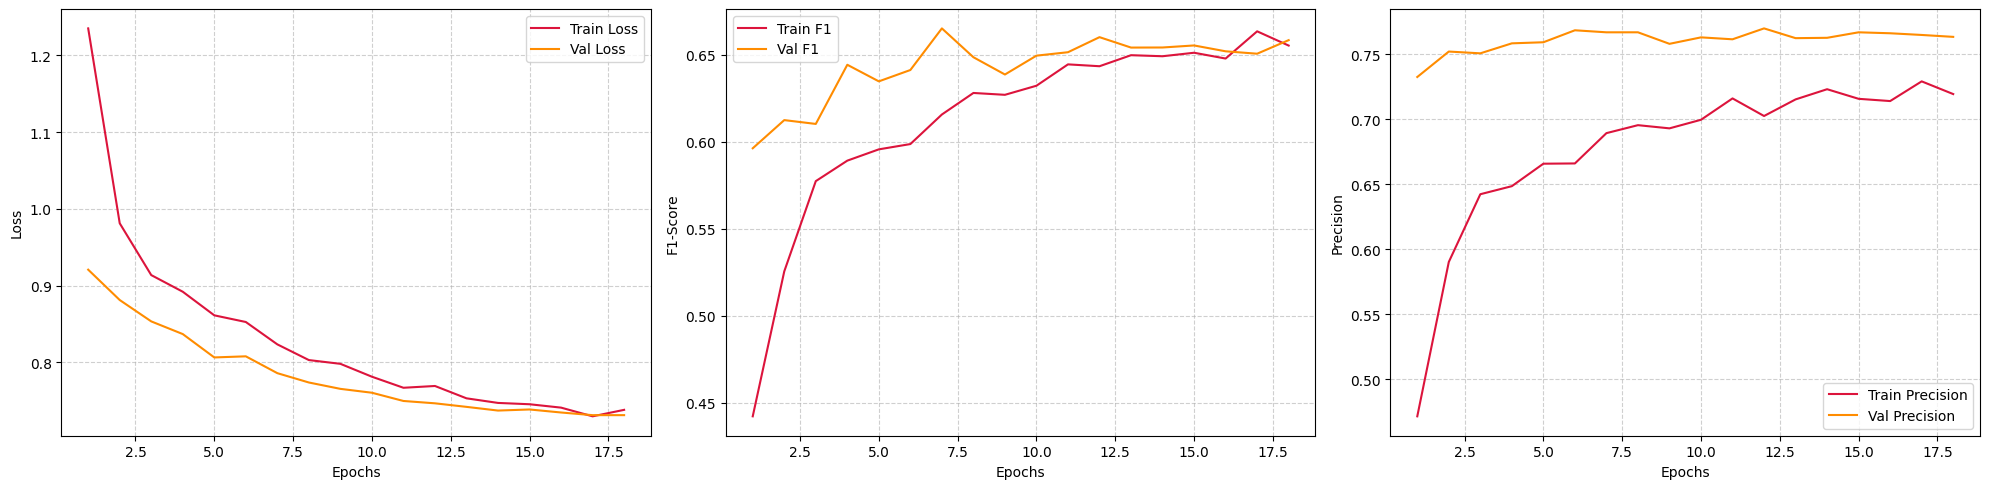

done


In [19]:
# ==========================================================
# PLOT LEARNING CURVES: PHASE 1 (INITIAL, LABELED-ONLY TRAINING)
# ==========================================================
print("start")

if 'history_initial' in globals():
    epochs_range = range(1, len(history_initial.history['loss']) + 1)
    plt.figure(figsize=(20, 5))

    plt.subplot(1, 3, 1)
    plt.plot(epochs_range, history_initial.history['loss'], label='Train Loss', color='crimson')
    plt.plot(epochs_range, history_initial.history['val_loss'], label='Val Loss', color='darkorange')
    plt.xlabel('Epochs'); plt.ylabel('Loss'); plt.legend(); plt.grid(True, linestyle='--', alpha=0.6)

    plt.subplot(1, 3, 2)
    plt.plot(epochs_range, history_initial.history['f1_score'], label='Train F1', color='crimson')
    plt.plot(epochs_range, history_initial.history['val_f1_score'], label='Val F1', color='darkorange')
    plt.xlabel('Epochs'); plt.ylabel('F1-Score'); plt.legend(); plt.grid(True, linestyle='--', alpha=0.6)

    plt.subplot(1, 3, 3)
    plt.plot(epochs_range, history_initial.history['precision'], label='Train Precision', color='crimson')
    plt.plot(epochs_range, history_initial.history['val_precision'], label='Val Precision', color='darkorange')
    plt.xlabel('Epochs'); plt.ylabel('Precision'); plt.legend(); plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.savefig("ResNet50_Wavelet_SemiSupervised_Initial_Learning_Curves_v5.pdf", format='pdf', bbox_inches='tight')
    plt.show()
else:
    print("Warning: history_initial not found. Did Phase 1 execute?")

print("done")


start


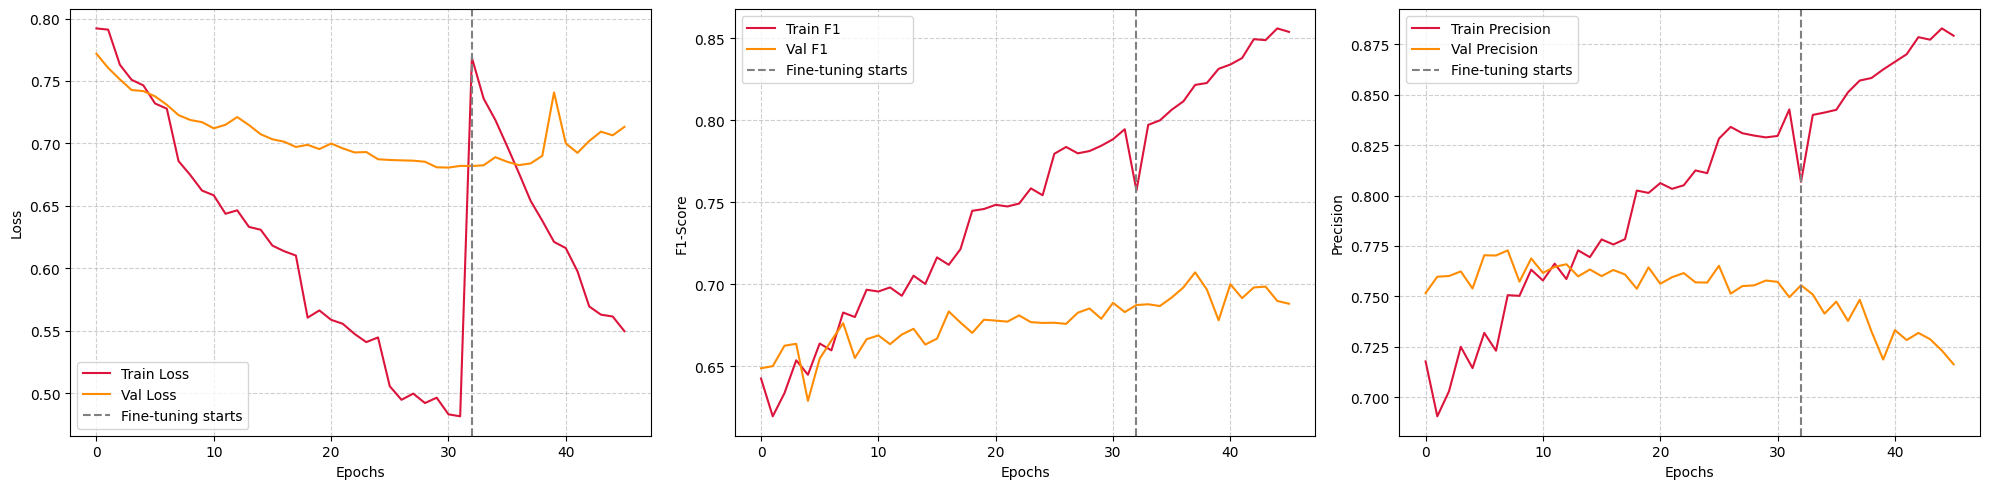

done1


In [20]:
# ==========================================================
# PLOT LEARNING CURVES: PHASE 2 (ITERATIVE SELF-TRAINING) + PHASE 3 (FINE-TUNE)
# ==========================================================
print("start")

def concat_history(h1_dict, h2_keras, key):
    return h1_dict.history[key] + h2_keras.history[key]

if 'history_final' in globals() and 'history_finetune' in globals():
    self_train_end = len(history_final.history['loss'])

    plt.figure(figsize=(20, 5))

    plt.subplot(1, 3, 1)
    plt.plot(concat_history(history_final, history_finetune, 'loss'), label='Train Loss', color='crimson')
    plt.plot(concat_history(history_final, history_finetune, 'val_loss'), label='Val Loss', color='darkorange')
    plt.axvline(self_train_end, linestyle='--', color='gray', label='Fine-tuning starts')
    plt.xlabel('Epochs'); plt.ylabel('Loss'); plt.legend(); plt.grid(True, linestyle='--', alpha=0.6)

    plt.subplot(1, 3, 2)
    plt.plot(concat_history(history_final, history_finetune, 'f1_score'), label='Train F1', color='crimson')
    plt.plot(concat_history(history_final, history_finetune, 'val_f1_score'), label='Val F1', color='darkorange')
    plt.axvline(self_train_end, linestyle='--', color='gray', label='Fine-tuning starts')
    plt.xlabel('Epochs'); plt.ylabel('F1-Score'); plt.legend(); plt.grid(True, linestyle='--', alpha=0.6)

    plt.subplot(1, 3, 3)
    plt.plot(concat_history(history_final, history_finetune, 'precision'), label='Train Precision', color='crimson')
    plt.plot(concat_history(history_final, history_finetune, 'val_precision'), label='Val Precision', color='darkorange')
    plt.axvline(self_train_end, linestyle='--', color='gray', label='Fine-tuning starts')
    plt.xlabel('Epochs'); plt.ylabel('Precision'); plt.legend(); plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.savefig("ResNet50_Wavelet_SemiSupervised_Final_Learning_Curves_v5.pdf", format='pdf', bbox_inches='tight')
    plt.show()
else:
    print("Warning: history_final / history_finetune not found.")

print("done1")


In [21]:
# ==========================================================
# FINAL EVALUATION: TRAINING, VALIDATION, AND TEST SETS
# ==========================================================
print("start")

train_eval_generator = ResNetWaveletGenerator(
    train_combined_dir, shuffle=False, labeled=True, augment=False,
    class_indices=train_labeled_generator.class_indices
)

print("\n--- Evaluating Training Dataset (labeled + pseudo-labeled, unaugmented view) ---")
train_results = model.evaluate(train_eval_generator, verbose=1)

print("\n--- Evaluating Validation Dataset ---")
val_results = model.evaluate(val_generator, verbose=1)

print("\n--- Evaluating Test Dataset (unseen) ---")
test_results = model.evaluate(test_generator, verbose=1)

train_loss, train_acc, train_f1, train_precision, train_recall = train_results
val_loss, val_acc, val_f1, val_precision, val_recall = val_results
test_loss, test_acc, test_f1, test_precision, test_recall = test_results

for name, (loss, acc, f1, prec, rec) in [
    ("TRAINING", (train_loss, train_acc, train_f1, train_precision, train_recall)),
    ("VALIDATION", (val_loss, val_acc, val_f1, val_precision, val_recall)),
    ("TESTING (UNSEEN DATA)", (test_loss, test_acc, test_f1, test_precision, test_recall)),
]:
    print("\n" + "=" * 40)
    print(f"{name} METRICS")
    print("=" * 40)
    print(f"Loss      : {loss:.4f}")
    print(f"Accuracy  : {acc*100:.2f}%")
    print(f"F1-Score  : {f1*100:.2f}%")
    print(f"Precision : {prec*100:.2f}%")
    print(f"Recall    : {rec*100:.2f}%")

print("done1")


start

--- Evaluating Training Dataset (labeled + pseudo-labeled, unaugmented view) ---
223/223 [==============================] - 92s 407ms/step - loss: 0.3554 - accuracy: 0.8648 - f1_score: 0.8135 - precision: 0.8469 - recall: 0.7653

--- Evaluating Validation Dataset ---
93/93 [==============================] - 40s 431ms/step - loss: 0.6839 - accuracy: 0.7056 - f1_score: 0.7073 - precision: 0.7483 - recall: 0.6449

--- Evaluating Test Dataset (unseen) ---
92/92 [==============================] - 40s 426ms/step - loss: 0.6950 - accuracy: 0.6867 - f1_score: 0.6859 - precision: 0.7452 - recall: 0.6371

TRAINING METRICS
Loss      : 0.3554
Accuracy  : 86.48%
F1-Score  : 81.35%
Precision : 84.69%
Recall    : 76.53%

VALIDATION METRICS
Loss      : 0.6839
Accuracy  : 70.56%
F1-Score  : 70.73%
Precision : 74.83%
Recall    : 64.49%

TESTING (UNSEEN DATA) METRICS
Loss      : 0.6950
Accuracy  : 68.67%
F1-Score  : 68.59%
Precision : 74.52%
Recall    : 63.71%
done1


In [22]:
# ==========================================================
# INFERENCE & CLASSIFICATION REPORT (Test Set)
# ==========================================================
print("start")

predictions_test = model.predict(test_generator, verbose=1)
predicted_classes_test = np.argmax(predictions_test, axis=1)
true_classes_test = test_generator.labels

print("\nClassification Report:")
print(classification_report(true_classes_test, predicted_classes_test, target_names=class_names))

print("done1")


start
92/92 [==============================] - 39s 422ms/step

Classification Report:
              precision    recall  f1-score   support

      Benign       0.55      0.57      0.56       888
   Malignant       0.70      0.76      0.73      1266
      Normal       0.85      0.70      0.77       789

    accuracy                           0.69      2943
   macro avg       0.70      0.68      0.69      2943
weighted avg       0.70      0.69      0.69      2943

done1


start


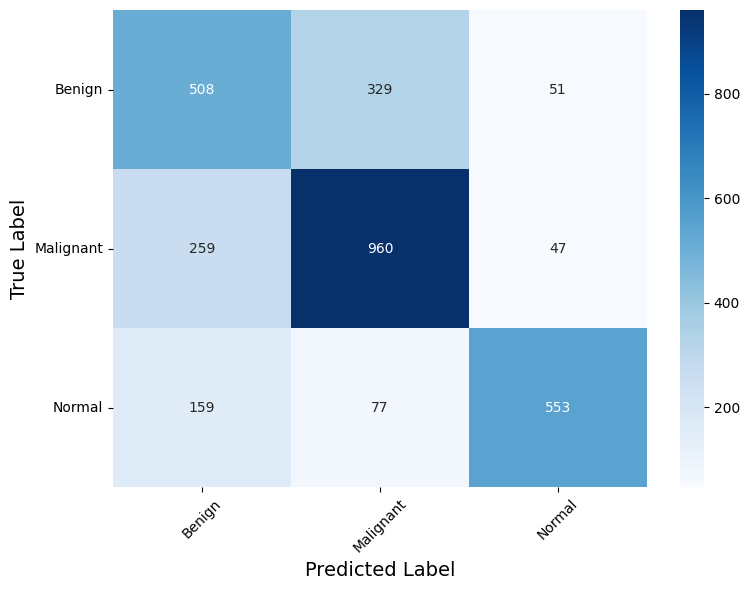


Raw confusion matrix (rows = true label, columns = predicted label):
Classes: ['Benign', 'Malignant', 'Normal']
[[508 329  51]
 [259 960  47]
 [159  77 553]]

Per-class error breakdown (where each class's mistakes actually go):

  True Benign (n=888): 508 correct (57.2%)
    -> misclassified as Malignant: 329 (37.0% of all Benign cases)
    -> misclassified as Normal: 51 (5.7% of all Benign cases)

  True Malignant (n=1266): 960 correct (75.8%)
    -> misclassified as Benign: 259 (20.5% of all Malignant cases)
    -> misclassified as Normal: 47 (3.7% of all Malignant cases)

  True Normal (n=789): 553 correct (70.1%)
    -> misclassified as Benign: 159 (20.2% of all Normal cases)
    -> misclassified as Malignant: 77 (9.8% of all Normal cases)

Benign-vs-Malignant target metric (n=2154, true label is Benign or Malignant; any prediction other than the true label -- including Normal -- counts as wrong):
  Accuracy: 68.15%  <- this is the number to compare across v4 vs v5
done1


In [23]:
# ==========================================================
# CONFUSION MATRIX -- PLOT, RAW NUMBERS, AND BENIGN-VS-MALIGNANT-ONLY ACCURACY  (v5: last part new)
# ==========================================================
print("start")

cm = confusion_matrix(true_classes_test, predicted_classes_test)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.ylabel('True Label', fontsize=14)
plt.xlabel('Predicted Label', fontsize=14)
plt.xticks(rotation=45); plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("ResNet50_Wavelet_SemiSupervised_confusion_matrix_test_v5.pdf", format='pdf', bbox_inches='tight')
plt.show()

print("\nRaw confusion matrix (rows = true label, columns = predicted label):")
print("Classes:", class_names)
print(cm)

print("\nPer-class error breakdown (where each class's mistakes actually go):")
for i, true_cls in enumerate(class_names):
    total = cm[i].sum()
    if total == 0:
        continue
    correct = cm[i, i]
    print(f"\n  True {true_cls} (n={total}): {correct} correct ({100*correct/total:.1f}%)")
    for j, pred_cls in enumerate(class_names):
        if i == j:
            continue
        n_err = cm[i, j]
        if n_err > 0:
            print(f"    -> misclassified as {pred_cls}: {n_err} ({100*n_err/total:.1f}% of all {true_cls} cases)")

# v5 NEW: track the actual target metric directly, instead of inferring it from the full report.
b_idx = class_indices["Benign"]
m_idx = class_indices["Malignant"]
pair_mask = np.isin(true_classes_test, [b_idx, m_idx])
if pair_mask.sum() > 0:
    pair_true = true_classes_test[pair_mask]
    pair_pred = predicted_classes_test[pair_mask]
    pair_acc = float(np.mean(pair_true == pair_pred))
    print(f"\nBenign-vs-Malignant target metric (n={int(pair_mask.sum())}, true label is Benign or "
          f"Malignant; any prediction other than the true label -- including Normal -- counts as wrong):")
    print(f"  Accuracy: {pair_acc*100:.2f}%  <- this is the number to compare across v4 vs v5")

print("done1")


## Notes & tunable hyperparameters (v5)

- **`PAIRWISE_BOOST_SCALE` (3.0)** -- if the Benign<->Malignant confusion is still severe after this
  run, raise this (e.g. to 5.0) before doing anything more invasive; if Normal's own accuracy drops
  noticeably (a side effect of boosting the other two too far), lower it instead.
- **`MARGIN_REQUIRED_FOR_PAIR` (0.25)** -- if self-training's per-iteration log shows Benign/Malignant
  now accepting very few pseudo-labels (because almost nothing clears the margin), lower this (e.g. to
  0.15) rather than removing the margin gate entirely -- the whole point is filtering out barely-decided
  calls, not blocking self-training on this pair altogether.
- **`GLCM_LEVELS` / `GLCM_DISTANCES` / `GLCM_ANGLES`** -- if training speed drops noticeably from the
  added feature cost, reduce `GLCM_ANGLES` to 2 directions or `GLCM_LEVELS` to 16 first, before dropping
  GLCM features altogether.
- **`USE_FOCAL_LOSS`** -- try turning this on if pairwise weighting alone doesn't move the
  Benign-vs-Malignant target metric enough. Start with `FOCAL_GAMMA = 2.0` (a common default);
  raising it further concentrates gradient even harder on the hardest examples.
- **The Benign-vs-Malignant-only accuracy** printed at the end of Phase 4 is now the number to track
  run over run for this specific problem -- it isolates the actual target from Normal's (already good)
  performance, which the overall macro F1 was diluting.
- Everything else (per-class threshold + cap for Normal, flip-only augmentation,
  `FINETUNE_UNFREEZE_LAST_N`, dropout/L2) unchanged from v4 -- no evidence yet that they need
  further adjustment.
- All checkpoints now save with a `_v5` suffix so they never overwrite your v4 `.h5` files.
